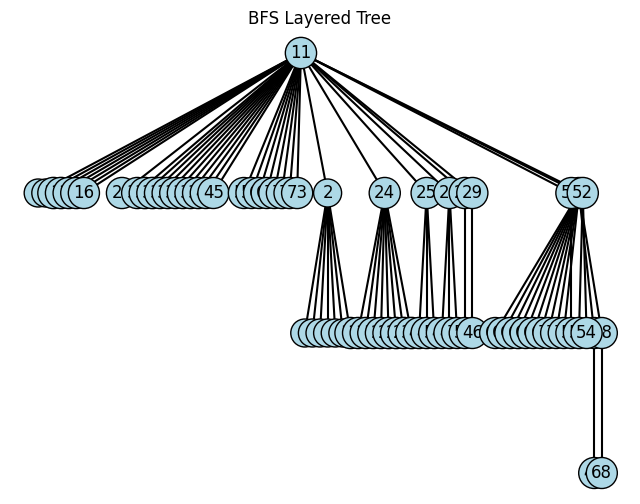

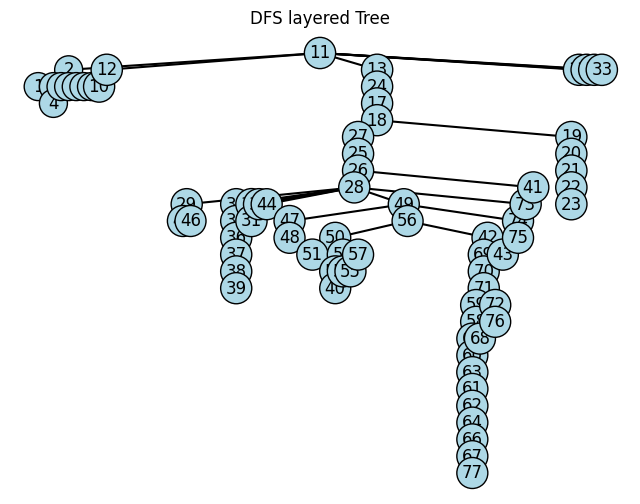

In [12]:
import pydot
import matplotlib.pyplot as plt
from collections import deque

def parse_dot_file(file_path):
    graph = pydot.graph_from_dot_file(file_path)[0]
    adjacency_list = {}

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        if src not in adjacency_list:
            adjacency_list[src] = []
        if dst not in adjacency_list:
            adjacency_list[dst] = []
        adjacency_list[src].append(dst)
        adjacency_list[dst].append(src)  # for undirected graph

    return adjacency_list

def bfs_tree(graph, root):
    visited = set()
    queue = deque([root])
    bfs_tree = {root: []}
    
    while queue:
        node = queue.popleft()
        visited.add(node)

        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                bfs_tree[node].append(neighbor)
                bfs_tree[neighbor] = []
    
    return bfs_tree

def dfs_tree(graph, root, visited=None, tree=None):
    if visited is None:
        visited = set()
    if tree is None:
        tree = {root: []}

    visited.add(root)

    for neighbor in graph.get(root, []):
        if neighbor not in visited:
            tree[root].append(neighbor)
            tree[neighbor] = []
            dfs_tree(graph, neighbor, visited, tree)

    return tree

def compute_postorder_spacing(tree, node, spacing, boundaries):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree:
        return

    leftmost, rightmost = None, None

    for child in tree[node]:
        compute_postorder_spacing(tree, child, spacing, boundaries)
        
        # Set boundaries for subtree
        if leftmost is None:
            leftmost = boundaries[child][0]
        rightmost = boundaries[child][1]

    if leftmost is not None:
        # Assign horizontal spacing based on children's boundaries
        boundaries[node] = (leftmost, rightmost)
        spacing[node] = (leftmost + rightmost) / 2
    else:
        # Leaf node case
        boundaries[node] = (spacing[node], spacing[node])

def assign_preorder_positions(tree, node, x_positions, y_positions, depth, spacing):
    """ Preorder traversal to assign final x and y coordinates. """
    x_positions[node] = spacing[node]
    y_positions[node] = -depth  # Negative depth for layered layout

    for child in tree[node]:
        assign_preorder_positions(tree, child, x_positions, y_positions, depth + 1, spacing)

def draw_layered_tree(tree, title="Level-Based Tree Layout"):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-')

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=12,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    plt.title(title)
    plt.axis('off')
    plt.show()

# Example usage
dot_file = "../Dataset/Step1/LesMiserables.dot" 
graph = parse_dot_file(dot_file)
root_node = "11"

bfs_result = bfs_tree(graph, root_node)
dfs_result = dfs_tree(graph, root_node)

draw_layered_tree(bfs_result, "BFS Layered Tree")
draw_layered_tree(dfs_result, "DFS layered Tree")

